# 1. Pre_Thickness_VM (전공정 두께 가상계측) — 알고리즘 교육 자료

CMP(Chemical Mechanical Polishing) 공정은 웨이퍼를 투입하기 **직전 두께**를 알아야
얼마나 깎을지(연마 시간 등 APC 파라미터)를 정확히 계산할 수 있습니다.

문제는 CMP 설비가 전공정(Pre-Oper) 장비에서 방금 나온 웨이퍼의 실제 투입 전 두께를
**직접 측정하지 않는다**는 점입니다. 그래서 과거 실적으로부터 전공정 장비/챔버별
두께 편차 패턴을 **학습**해 대신 추정합니다 — 이것이 **Pre_Thk_VM**
(Pre-Thickness Virtual Metrology) 입니다.

이 노트북은 실제 프로덕션 코드 `algorithm_new/Common/PRE_THK_VM.py` 의 함수들을
**그대로 호출**하면서, 각 단계에서 데이터가 어떻게 바뀌는지 하나씩 실행하고
트렌드/테이블로 확인합니다.

```
전체 흐름
────────────────────────────────────────────────────────────────────
 merge_df (CMP 실측 데이터: 웨이퍼 1행 = 1행)
   │
   ├─ [준비]   BIAS 계산            0-centering (CMP 후 두께 편차)
   │
   ├─ [Step 1] compute_detrend()     ← PRE_THK_VM_Get
   │      실제 연마시간 대신 "평균 연마시간"을 적용했다면 나왔을 두께(Unctr_Thk)를
   │      역산하고, 패드 교체 주기별로 이동평균을 빼 추세(드리프트)만 남깁니다.
   │
   ├─ [Step 2] iqr_filter()          ← PRE_THK_VM_Get
   │      IQR(사분위 범위) 기준 이상치를 제거합니다.
   │
   ├─ [Step 3] rolling_mean()        ← PRE_THK_VM_Get
   │      전공정 장비_채널(pre_eq_ch)별로 최근 N일 이동평균 → Pre_Thk 학습값
   │
   └─ [Step 4] _extract_latest()     ← Common.Module
          채널별 가장 최근 1건만 뽑아 **최종 학습값**으로 확정합니다.
────────────────────────────────────────────────────────────────────
```

> 실행 조건: 셀을 위에서부터 순서대로 하나씩 실행하세요. 각 Step 마다 계산 결과를
> 트렌드 그래프 또는 표로 바로 확인할 수 있습니다.

## 0. 환경 설정

MongoDB, Cube 메신저 등 사내 시스템은 이 교육 자료에서 필요하지 않으므로 사용하지
않습니다. `algorithm_new/Common/PRE_THK_VM.py` 는 pandas/numpy/scikit-learn 만
사용하는 순수 계산 모듈이라 별도 Mock 없이 바로 임포트할 수 있습니다.

그래프는 기본 matplotlib 스타일 대신, 여백/그리드/색상을 정돈한 커스텀 스타일
(`style_ax`, `PALETTE`)을 아래에서 한 번만 정의하고 이후 모든 그래프에 재사용합니다.

In [1]:
import sys
from pathlib import Path

ALGO_DIR = Path('..') / 'algorithm_new'
sys.path.insert(0, str(ALGO_DIR))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager

# ── 한글 폰트 자동 탐색 (Mac/Windows/Linux 어디서 열어도 한글이 깨지지 않도록) ──
_KOREAN_FONTS = ['AppleGothic', 'Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'Noto Sans CJK KR']
_installed = {f.name for f in font_manager.fontManager.ttflist}
_font = next((f for f in _KOREAN_FONTS if f in _installed), None)
# 한글 폰트를 1순위로, DejaVu Sans를 2순위로 두면 Å 같은 특수기호는
# 한글 폰트에 없어도 자동으로 DejaVu Sans에서 대체 렌더링됨 (matplotlib 폰트 폴백)
plt.rcParams['font.family'] = [_font, 'DejaVu Sans'] if _font else ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ── 깔끔한 트렌드 스타일 (기본 matplotlib 스타일 대신 사용) ──────────────
INK_PRIMARY   = '#0b0b0b'   # 제목/본문
INK_SECONDARY = '#52514e'   # 축 라벨
INK_MUTED     = '#898781'   # 눈금
GRID          = '#e1e0d9'   # 그리드선 (아주 옅게)
BASELINE      = '#c3c2b7'   # 축선
SURFACE       = '#fcfcfb'   # 차트 배경

# 카테고리 색상은 항상 같은 순서로 고정 사용 (장비/채널이 늘어나도 임의로 섞지 않음)
PALETTE = ['#2a78d6', '#1baf7a', '#eda100', '#008300',
           '#4a3aa7', '#e34948', '#e87ba4', '#eb6834']
RAW_COLOR = '#b7d3f6'   # 원본(raw) 산점 — 옅은 블루, MA 라인과 구분

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor'  : SURFACE,
    'axes.edgecolor'  : BASELINE,
    'axes.labelcolor' : INK_SECONDARY,
    'text.color'      : INK_PRIMARY,
    'xtick.color'     : INK_MUTED,
    'ytick.color'     : INK_MUTED,
    'font.size'       : 10,
    'figure.dpi'      : 110,
})

def style_ax(ax, title=None, ylabel=None, xlabel=None, legend=True, legend_loc='best'):
    # 모든 그래프에 공통 적용하는 정돈된 스타일 (spine 정리 + 옅은 그리드 + 좌측 정렬 제목)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color(BASELINE)
        ax.spines[spine].set_linewidth(0.8)
    ax.set_axisbelow(True)
    ax.grid(axis='y', color=GRID, linewidth=0.8)
    ax.tick_params(labelsize=8.5, length=0)
    if title:
        ax.set_title(title, fontsize=11, fontweight='bold', color=INK_PRIMARY, loc='left', pad=10)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9)
    if legend and ax.get_legend_handles_labels()[0]:
        leg = ax.legend(fontsize=8, frameon=False, loc=legend_loc)
    return ax

print(f'환경 설정 완료 — 정돈된 트렌드 스타일 적용됨 (한글 폰트: {_font or "시스템 기본값, 한글 폰트 미탐지"})')

환경 설정 완료 — 정돈된 트렌드 스타일 적용됨 (한글 폰트: NanumGothic)


## 1. 데이터 & Set-up 파라미터 준비

- **merge_df** : CMP 실측 데이터 샘플 (`algorithm_new/merge_df_sample.csv`).
  실제 운영 환경에서는 MongoDB에서 조회하지만(`Get_data.MongoDB_GetData`),
  이 파일은 동일한 컬럼 구조를 가진 합성(synthetic) 데이터입니다.
- **mico_info_key** : Set-up 정보(Category/SubCategory/Detail). 실제 운영에서는
  Django DB에서 `Get_data.baseinfoGetData()` 로 조회하지만, 이 교육 자료에서는
  DB 연결 없이 바로 실행할 수 있도록 **DRAM M1 CU CMP 공정의 실제 Set-up 값**을
  그대로 입력해 사용합니다 (`compare_algorithms.py` 검증에 사용된 값과 동일).

| 파라미터 | 값 | 의미 |
|---|---|---|
| `APC_Para` | `P3` | 연마 시간을 담는 APC 파라미터 컬럼 |
| `Thk_Para` | `AMAT_POST_OCD_AVG` | CMP 후 두께 계측값 컬럼 |
| `Pre_Target` | 2350 Å | CMP 투입 **전** 목표 두께 |
| `Target` (Post_Target) | 1900 Å | CMP 후 목표 두께 |
| `Pre_Thk_Period` | 3 (일) | Pre_Thk 이동평균 윈도우 |
| `Pre_Oper_Code` | `A111111B` | 전공정 코드 설정됨 → **Detrend + MA 경로** 사용 |
| `FB_Type` | `TIME` | 시간 기준 피드백 (Pressure 아님) |

In [2]:
from Common.Get_Data import Get_data
from Common.PRE_THK_VM import PRE_THK_VM_Get

# ── CMP 실측 데이터 로드 ─────────────────────────────────────────────
merge_df = pd.read_csv(ALGO_DIR / 'merge_df_sample.csv', parse_dates=['Date', 'pre_oper_time'])
merge_df['IDLE'] = merge_df['IDLE'].fillna('')

# ── Set-up 정보 (실제 DRAM M1 CU CMP 값. 운영 환경에서는 Django DB 조회로 대체) ──
mico_info_key = pd.DataFrame([{
    'Family': 'DRAM', 'Lot_Code': 'LC', 'Oper_Code': 'V5077000E', 'Oper_Desc': 'M1 CU CMP',
    'Fab': 'M10', 'Maker': 'AMAT', 'Recipe_ID': 'E2_M1CU_R12_TSV.CAS',
    'APC_Para': 'P3', 'Thk_Para': 'AMAT_POST_OCD_AVG',
    'Target': 1900.0, 'Pre_Target': 2350.0, 'Pre_Thk_Period': 3,
    'Pre_Thk_Para_ITM': '', 'Pre_Oper_Code': 'A111111B',
    'Pre_Oper_Code2': '', 'FB_Type': 'TIME', 'Group_Name': 'not_group',
}])

Oper_Code       = mico_info_key['Oper_Code'].iloc[0]
APC_Para        = mico_info_key['APC_Para'].iloc[0]
Thk_Para        = mico_info_key['Thk_Para'].iloc[0]
Pre_Target      = float(mico_info_key['Pre_Target'].iloc[0])
Post_Target     = float(mico_info_key['Target'].iloc[0])
Pre_Thk_Period  = str(mico_info_key['Pre_Thk_Period'].iloc[0]) + 'D'
Pad_Para        = Get_data.PadParaGet(APC_Para)                 # 'AMAT_PAD_3'
APC_Para_merge  = Get_data.APCParaGet(APC_Para, pol_type=3)      # ['P3']

# 이 공정 Oper_Code 데이터만 필터링 (Module.py 의 _run_single 과 동일한 필터)
merge_df = merge_df[merge_df['operation_id'] == Oper_Code].copy()

print(f'merge_df : {merge_df.shape[0]:,}행  (기간 {merge_df["Date"].min().date()} ~ {merge_df["Date"].max().date()})')
print(f'CMP 장비 : {sorted(merge_df["eqp_id"].unique())}')
print(f'전공정 장비_채널 조합 : {(merge_df["pre_eqp_id"] + "_" + merge_df["pre_eqp_ch"].astype(str)).nunique()}개')
print(f'Pad_Para : {Pad_Para}   |   APC_Para_merge : {APC_Para_merge}   |   Pre_Thk_Period : {Pre_Thk_Period}')

merge_df : 20,000행  (기간 2026-04-16 ~ 2026-05-16)
CMP 장비 : ['KCMP41', 'KCMP42', 'KCMP43', 'KCMP44', 'KCMP45']
전공정 장비_채널 조합 : 16개
Pad_Para : AMAT_PAD_3   |   APC_Para_merge : ['P3']   |   Pre_Thk_Period : 3D


## 2. 실행 경로 판단 — ITM? Detrend+MA? 회귀만?

`Common/Module.py` 의 `compute_pre_thk_vm()` 은 Set-up 값에 따라 자동으로 아래 3가지
중 하나(또는 조합)로 분기합니다.

| 경로 | 조건 | 이 예제에서는? |
|---|---|---|
| **ITM** | `Pre_Thk_Para_ITM` 설정됨 (전공정 계측값 존재) | ❌ 미설정 |
| **Detrend + MA** | `Pre_Oper_Code` 설정됨 (전공정 코드로 데이터 연결) | ✅ `'A111111B'` 설정됨 |
| **Pre_Oper2~4 회귀** | `Pre_Oper_Code2` 설정됨 | ❌ 미설정 |

즉 이 예제는 **Detrend + MA 경로만** 사용합니다 — Step 1~4가 여기 해당합니다.

In [3]:
key = mico_info_key.iloc[0]
use_itm         = isinstance(key['Pre_Thk_Para_ITM'], str) and key['Pre_Thk_Para_ITM'] != ''
use_moving_avg  = (not use_itm) and isinstance(key['Pre_Oper_Code'], str) and key['Pre_Oper_Code'] != ''
has_regression  = isinstance(key['Pre_Oper_Code2'], str) and key['Pre_Oper_Code2'] != ''

print(f'ITM 경로 사용        : {use_itm}')
print(f'Detrend+MA 경로 사용 : {use_moving_avg}')
print(f'Pre_Oper2~4 회귀 사용 : {has_regression}')
print()
print('→ 이 노트북은 Detrend + MA 경로(Step 1~4)를 따라갑니다.')

ITM 경로 사용        : False
Detrend+MA 경로 사용 : True
Pre_Oper2~4 회귀 사용 : False

→ 이 노트북은 Detrend + MA 경로(Step 1~4)를 따라갑니다.


## 3. 준비 — BIAS (0-centering)

```python
# Module.py compute_pre_thk_vm() 내부 코드 (Detrend+MA 경로)
merge_df['BIAS'] = (merge_df[Thk_Para] - merge_df[Thk_Para_13P]) - (Post_Target - Target_13P)
```

BIAS는 **PRESSURE(ED/EX) 방식**이거나 **그룹 공정**처럼 `Thk_Para` 가 기준 파라미터
(`Thk_Para_13P`)와 다를 때 두 파라미터 간 오프셋을 제거하기 위한 값입니다.

이 예제(DRAM M1 CU CMP, `FB_Type='TIME'`, 단독 공정)는 `Thk_Para == Thk_Para_13P` 이고
`Post_Target == Target_13P` 이므로 **BIAS는 항상 0** 이 됩니다. 실제로 이어지는
`compute_detrend()` 도 `use_pressure=False` 일 때는 BIAS가 아니라 `Thk_Para` 원본값을
직접 사용하므로, 이 경로에서 BIAS는 참고용으로만 계산되고 실제 학습에는 쓰이지
않습니다.

In [4]:
Thk_Para_13P = Thk_Para   # 이 예제는 동일 파라미터 (그룹 공정이 아니므로)
Target_13P   = Post_Target

merge_df['BIAS'] = (merge_df[Thk_Para] - merge_df[Thk_Para_13P]) - (Post_Target - Target_13P)

print(f'BIAS 고유값: {merge_df["BIAS"].unique()}   (그룹 공정이 아니므로 항상 0)')

BIAS 고유값: [0.]   (그룹 공정이 아니므로 항상 0)


## Step 1 — `compute_detrend()` : 두께 드리프트 추출

```python
# PRE_THK_VM.py  compute_detrend()  핵심 로직
Pol_Time  = APC_Para_merge 합           # 총 연마 시간
RR        = (Pre_Target - Thk) / Pol_Time         # 실측 연마율(Removal Rate)

FIX_Time  = 전체 평균 Pol_Time                      # 장비 공통 기준 연마시간

for (eqp, recipe) 조합:
    Unctr_Thk  = Pre_Target - (RR * FIX_Time)      # "고정 시간 기준" 두께로 역산
    pad_cycle  = (Pad_Para 급감 시점) 기준 구간 번호  # 패드 교체 시점 분리

    for pad_cycle 구간:
        Unctr_Thk_MA = Unctr_Thk 의 rolling(10) 평균

    Detrend_Thk = Unctr_Thk - Unctr_Thk_MA         # 추세 제거 → 0-centered 드리프트
```

**왜 이렇게 계산할까?** 실제 연마 시간(`Pol_Time`)은 APC가 매 웨이퍼마다 다르게
조정하므로, 두께 원본값만 보면 "APC가 잘 조정한 결과"와 "전공정 두께 편차"가
섞여 있습니다. 연마 시간을 **고정값(FIX_Time)** 으로 통일해 두께를 역산하면
APC 보정 효과가 제거되어, 남은 변동은 전공정에서 온 두께 편차(드리프트)만
남습니다. 여기에 패드 사이클별 이동평균을 빼면 그 드리프트의 **순간 편차**만
0-centered 값으로 얻어집니다 — 이게 `Detrend_Thk` 입니다.

In [5]:
pre_thk_df = PRE_THK_VM_Get.compute_detrend(
    merge_df, APC_Para_merge, Thk_Para, Pre_Target, Post_Target, Pad_Para, use_pressure=False
)

print(f'compute_detrend 결과: {len(pre_thk_df):,}행')
print(f'장비 x 레시피 조합  : {pre_thk_df.groupby(["eqp_id","recipe_id"]).ngroups}개')
print(f'Detrend_Thk 결측    : {pre_thk_df["Detrend_Thk"].isna().sum()}건 (사이클 초반, MA 미산출)')
pre_thk_df[['Date','eqp_id','recipe_id','Pol_Time','RR','Unctr_Thk','pad_cycle','Unctr_Thk_MA','Detrend_Thk']].head(8)

compute_detrend 결과: 19,030행
장비 x 레시피 조합  : 10개
Detrend_Thk 결측    : 306건 (사이클 초반, MA 미산출)


,Date,eqp_id,recipe_id,Pol_Time,RR,Unctr_Thk,pad_cycle,Unctr_Thk_MA,Detrend_Thk
0,2026-04-16 01:29:55.304633,KCMP45,E2_M1CU_R12_TSV.CAS,18.213,18.830033,1821.631300,1,NaN,NaN
1,2026-04-16 01:41:03.831303,KCMP45,E2_M1CU_R12_TSV.CAS,23.702,17.422876,1861.115995,1,NaN,NaN
2,2026-04-16 01:52:19.576705,KCMP45,E2_M1CU_R12_TSV.CAS,20.251,22.831959,1709.337706,1,NaN,NaN
3,2026-04-16 02:26:09.215869,KCMP45,E2_M1CU_R12_TSV.CAS,23.366,18.959407,1818.001098,1,NaN,NaN
4,2026-04-16 02:37:52.301595,KCMP45,E2_M1CU_R12_TSV.CAS,21.805,18.619436,1827.540645,1,NaN,NaN
5,2026-04-16 03:10:36.201863,KCMP45,E2_M1CU_R12_TSV.CAS,20.305,18.642684,1826.888304,1,NaN,NaN
6,2026-04-16 03:21:54.119602,KCMP45,E2_M1CU_R12_TSV.CAS,23.723,19.904308,1791.487272,1,NaN,NaN
7,2026-04-16 03:32:34.816249,KCMP45,E2_M1CU_R12_TSV.CAS,22.184,17.629287,1855.324120,1,NaN,NaN


### Step 1-1. Pol_Time (연마시간) & RR (실측 연마율)

findfont: Failed to find font weight bold, now using 600.


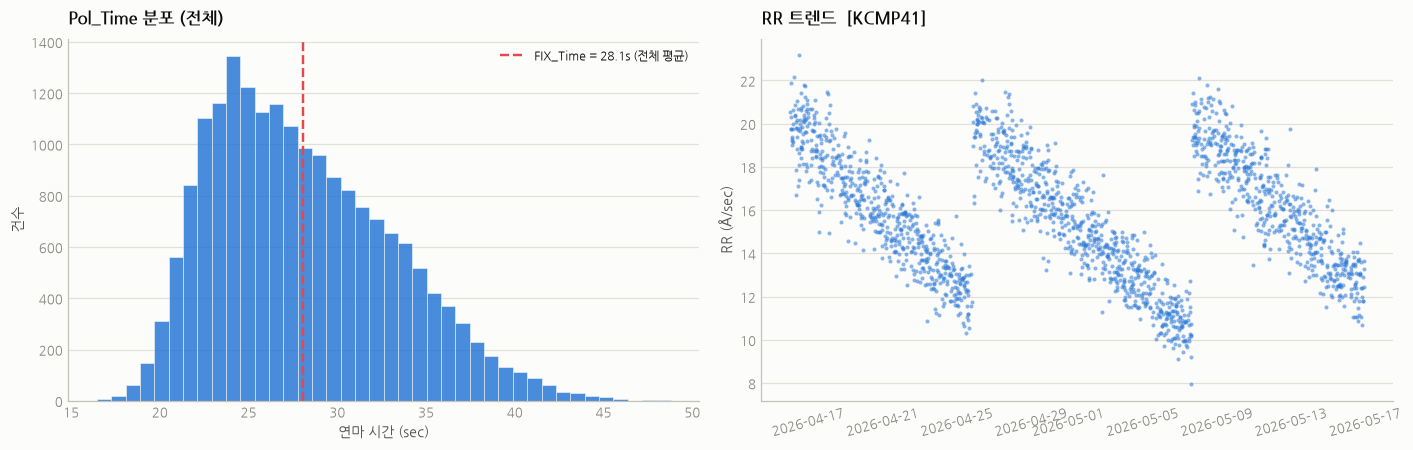

FIX_Time (전체 평균 연마시간) = 28.06 sec


In [6]:
FIX_Time = pre_thk_df['Pol_Time'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# ① Pol_Time 분포
ax = axes[0]
ax.hist(pre_thk_df['Pol_Time'], bins=40, color=PALETTE[0], alpha=0.85, edgecolor=SURFACE, linewidth=0.4)
ax.axvline(FIX_Time, color=PALETTE[5], linewidth=1.6, linestyle='--', label=f'FIX_Time = {FIX_Time:.1f}s (전체 평균)')
style_ax(ax, title='Pol_Time 분포 (전체)', ylabel='건수', xlabel='연마 시간 (sec)')

# ② 대표 1개 장비/레시피의 RR 트렌드
DEMO_EQP, DEMO_RCP = 'KCMP41', 'E2_M1CU_R12_TSV.CAS'
demo = pre_thk_df[(pre_thk_df.eqp_id == DEMO_EQP) & (pre_thk_df.recipe_id == DEMO_RCP)].sort_values('Date')
ax = axes[1]
ax.scatter(demo['Date'], demo['RR'], s=7, alpha=0.55, color=PALETTE[0], linewidths=0)
style_ax(ax, title=f'RR 트렌드  [{DEMO_EQP}]', ylabel='RR (Å/sec)', legend=False)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print(f'FIX_Time (전체 평균 연마시간) = {FIX_Time:.2f} sec')

### Step 1-2. 패드 사이클 분리 → Unctr_Thk → Detrend_Thk (대표 장비)

```python
temp_df2['pad_cycle'] = (temp_df2[Pad_Para].diff() < -0.5).cumsum() + 1
```

패드 소모량이 이전 행보다 0.5 이상 급감하면 패드 교체로 간주해 사이클 번호를
새로 매깁니다. 사이클마다 별도로 이동평균을 계산해야 패드 교체 시점의 두께
점프가 추세에 섞이지 않습니다.

findfont: Failed to find font weight bold, now using 600.


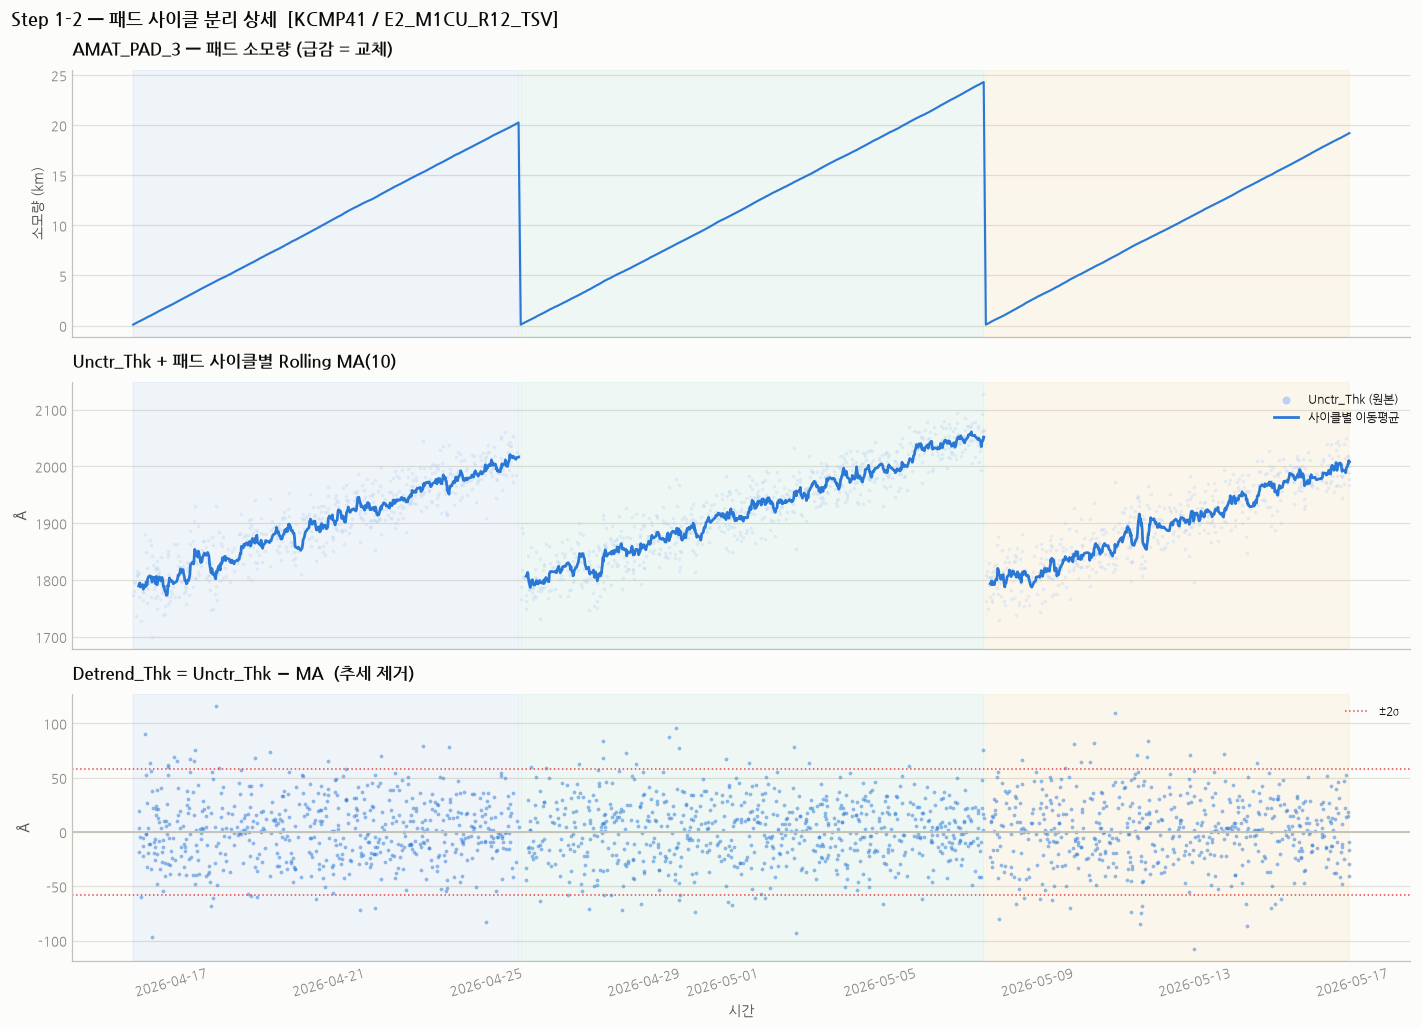

Detrend_Thk 평균 1.61 Å (0에 근접해야 정상)  |  표준편차 29.22 Å


In [7]:
demo = pre_thk_df[(pre_thk_df.eqp_id == DEMO_EQP) & (pre_thk_df.recipe_id == DEMO_RCP)] \
        .sort_values('Date').reset_index(drop=True)
cycles = sorted(demo['pad_cycle'].unique())

fig, axes = plt.subplots(3, 1, figsize=(13, 9.5), sharex=True)
fig.suptitle(f'Step 1-2 — 패드 사이클 분리 상세  [{DEMO_EQP} / {DEMO_RCP.split(".")[0]}]',
             fontsize=12, fontweight='bold', color=INK_PRIMARY, x=0.01, ha='left')

# 사이클 경계를 옅은 배경으로 표시 (팔레트 순서 고정 반복)
bounds = demo.groupby('pad_cycle')['Date'].agg(['min', 'max'])
for ax in axes:
    for cyc, row in bounds.iterrows():
        ax.axvspan(row['min'], row['max'], color=PALETTE[(cyc - 1) % len(PALETTE)], alpha=0.06)

# ① 패드 소모량
ax = axes[0]
ax.plot(demo['Date'], demo[Pad_Para], color=PALETTE[0], linewidth=1.4)
style_ax(ax, title=f'{Pad_Para} — 패드 소모량 (급감 = 교체)', ylabel='소모량 (km)', legend=False)

# ② Unctr_Thk + 사이클별 MA
ax = axes[1]
for cyc in cycles:
    c = demo[demo.pad_cycle == cyc]
    ax.scatter(c['Date'], c['Unctr_Thk'], s=5, alpha=0.35, color=RAW_COLOR, linewidths=0)
    c_ma = c.dropna(subset=['Unctr_Thk_MA'])
    if len(c_ma) > 1:
        ax.plot(c_ma['Date'], c_ma['Unctr_Thk_MA'], color=PALETTE[0], linewidth=1.8)
ax.scatter([], [], s=18, color=RAW_COLOR, label='Unctr_Thk (원본)')
ax.plot([], [], color=PALETTE[0], linewidth=1.8, label='사이클별 이동평균')
style_ax(ax, title='Unctr_Thk + 패드 사이클별 Rolling MA(10)', ylabel='Å')

# ③ Detrend_Thk (최종 드리프트)
ax = axes[2]
det = demo.dropna(subset=['Detrend_Thk'])
sigma = det['Detrend_Thk'].std()
ax.scatter(det['Date'], det['Detrend_Thk'], s=6, alpha=0.5, color=PALETTE[0], linewidths=0)
ax.axhline(0, color=BASELINE, linewidth=1.2)
ax.axhline(2*sigma, color=PALETTE[5], linewidth=1, linestyle=':')
ax.axhline(-2*sigma, color=PALETTE[5], linewidth=1, linestyle=':', label='±2σ')
style_ax(ax, title='Detrend_Thk = Unctr_Thk − MA  (추세 제거)', ylabel='Å', xlabel='시간')
axes[-1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print(f'Detrend_Thk 평균 {det["Detrend_Thk"].mean():.2f} Å (0에 근접해야 정상)  |  표준편차 {sigma:.2f} Å')

### Step 1-3. 전체 장비 비교

장비별로 Detrend_Thk 분포를 비교하면, 어떤 CMP 설비가 전공정 편차에 더 민감한지
한눈에 볼 수 있습니다.

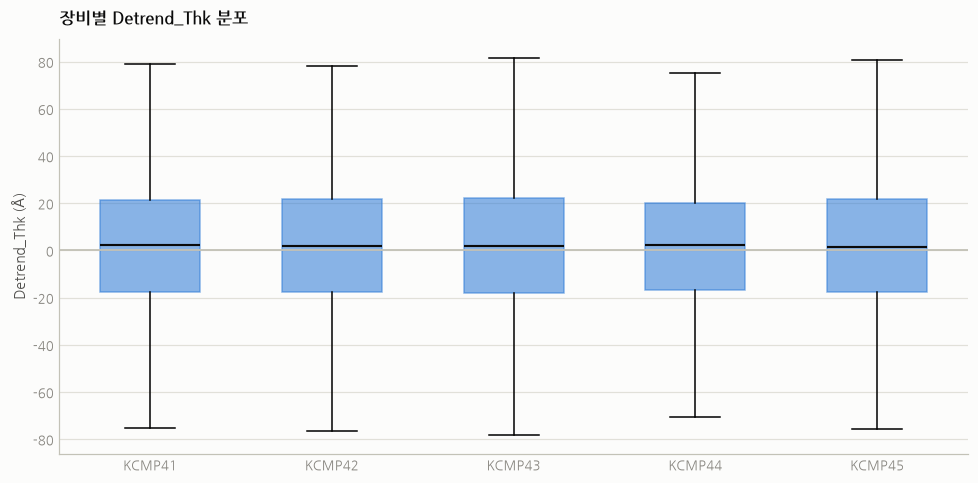

In [8]:
det_all = pre_thk_df.dropna(subset=['Detrend_Thk'])
eqp_list = sorted(det_all['eqp_id'].unique())

fig, ax = plt.subplots(figsize=(9, 4.5))
bp_data = [det_all[det_all.eqp_id == e]['Detrend_Thk'].values for e in eqp_list]
bp = ax.boxplot(bp_data, tick_labels=eqp_list, patch_artist=True, showfliers=False, widths=0.55,
                 medianprops=dict(color=INK_PRIMARY, linewidth=1.4))
for patch in bp['boxes']:
    patch.set_facecolor(PALETTE[0]); patch.set_alpha(0.55); patch.set_edgecolor(PALETTE[0])
ax.axhline(0, color=BASELINE, linewidth=1.2)
style_ax(ax, title='장비별 Detrend_Thk 분포', ylabel='Detrend_Thk (Å)', legend=False)

plt.tight_layout()
plt.show()

## Step 2 — `iqr_filter()` : 이상치 제거

```python
q1, q3 = df[col].quantile([0.25, 0.75])
IQR    = q3 - q1
return df[(df[col] >= q1 - sigma*IQR) & (df[col] <= q3 + sigma*IQR)]   # sigma=3
```

평균/표준편차 방식은 이상치 자체가 평균·표준편차를 왜곡시키지만, IQR(사분위 범위)
방식은 중앙 50% 데이터만 기준으로 삼기 때문에 극단값에 흔들리지 않습니다.
`sigma=3` 은 정규분포 기준 약 99.7% 데이터를 보존하는 수준입니다.

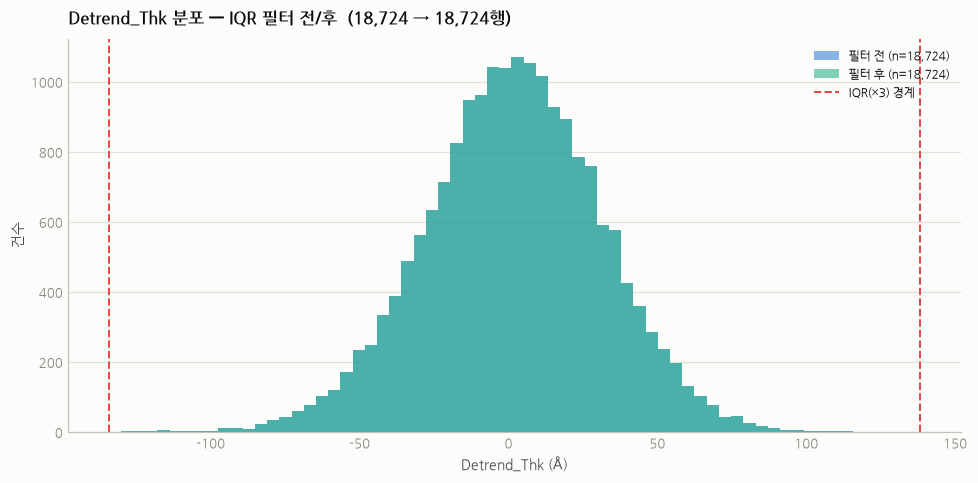

IQR 경계: LCL=-134.2Å, UCL=138.2Å  |  제거 0건 (0.00%)


In [9]:
pre_thk_df_filtered = PRE_THK_VM_Get.iqr_filter(pre_thk_df, 'Detrend_Thk')

before = pre_thk_df['Detrend_Thk'].dropna()
after  = pre_thk_df_filtered['Detrend_Thk']
q1, q3 = before.quantile([0.25, 0.75]); iqr = q3 - q1
lcl, ucl = q1 - 3*iqr, q3 + 3*iqr

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(before, bins=60, color=PALETTE[0], alpha=0.55, label=f'필터 전 (n={len(before):,})')
ax.hist(after,  bins=60, color=PALETTE[1], alpha=0.55, label=f'필터 후 (n={len(after):,})')
ax.axvline(lcl, color=PALETTE[5], linewidth=1.3, linestyle='--')
ax.axvline(ucl, color=PALETTE[5], linewidth=1.3, linestyle='--', label=f'IQR(×3) 경계')
style_ax(ax, title=f'Detrend_Thk 분포 — IQR 필터 전/후  ({len(before):,} → {len(after):,}행)',
         xlabel='Detrend_Thk (Å)', ylabel='건수')

plt.tight_layout()
plt.show()
print(f'IQR 경계: LCL={lcl:.1f}Å, UCL={ucl:.1f}Å  |  제거 {len(before)-len(after)}건 ({(len(before)-len(after))/len(before)*100:.2f}%)')

## Step 3 — `rolling_mean()` : 전공정 채널별 이동평균 → Pre_Thk

```python
df['pre_eq_ch'] = df['pre_eqp_id'] + '_' + df['pre_eqp_ch']    # 전공정 장비_채널 키

for pre_eq_ch 별:
    Pre_Thk       = Detrend_Thk 의 rolling(window=Pre_Thk_Period, on='pre_oper_time').mean()
    Pre_Thk_Count = 같은 윈도우의 유효 건수
```

`pre_oper_time`(전공정 처리 시각) 기준으로 최근 `Pre_Thk_Period`(3일) 동안의
`Detrend_Thk` 평균이 그 채널의 **Pre_Thk 학습값**입니다. 데이터가 `min_count`
건 미만이면 아직 신뢰할 수 없다고 보고 결측(NaN) 처리합니다.

In [10]:
pre_thk_df_rolled = PRE_THK_VM_Get.rolling_mean(pre_thk_df_filtered, 'Detrend_Thk', Pre_Thk_Period, min_count=10)

valid = pre_thk_df_rolled.dropna(subset=['Pre_Thk'])
print(f'rolling_mean 결과 : {len(pre_thk_df_rolled):,}행')
print(f'pre_eq_ch 채널 수 : {pre_thk_df_rolled["pre_eq_ch"].nunique()}개')
print(f'Pre_Thk 유효 건수 : {len(valid):,}행 (min_count=10 미달 구간은 NaN)')

valid.groupby('pre_eq_ch').size().sort_values(ascending=False).rename('유효 건수').to_frame()

rolling_mean 결과 : 18,724행
pre_eq_ch 채널 수 : 16개
Pre_Thk 유효 건수 : 18,580행 (min_count=10 미달 구간은 NaN)


,유효 건수
pre_eq_ch,
6KTSD502_1,1236
6KTSD501_1,1211
6KTSD505_1,1187
6KTSD501_2,1186
6KTSD504_1,1183
6KTSD508_2,1173
6KTSD502_2,1166
6KTSD505_2,1164
6KTSD503_2,1160


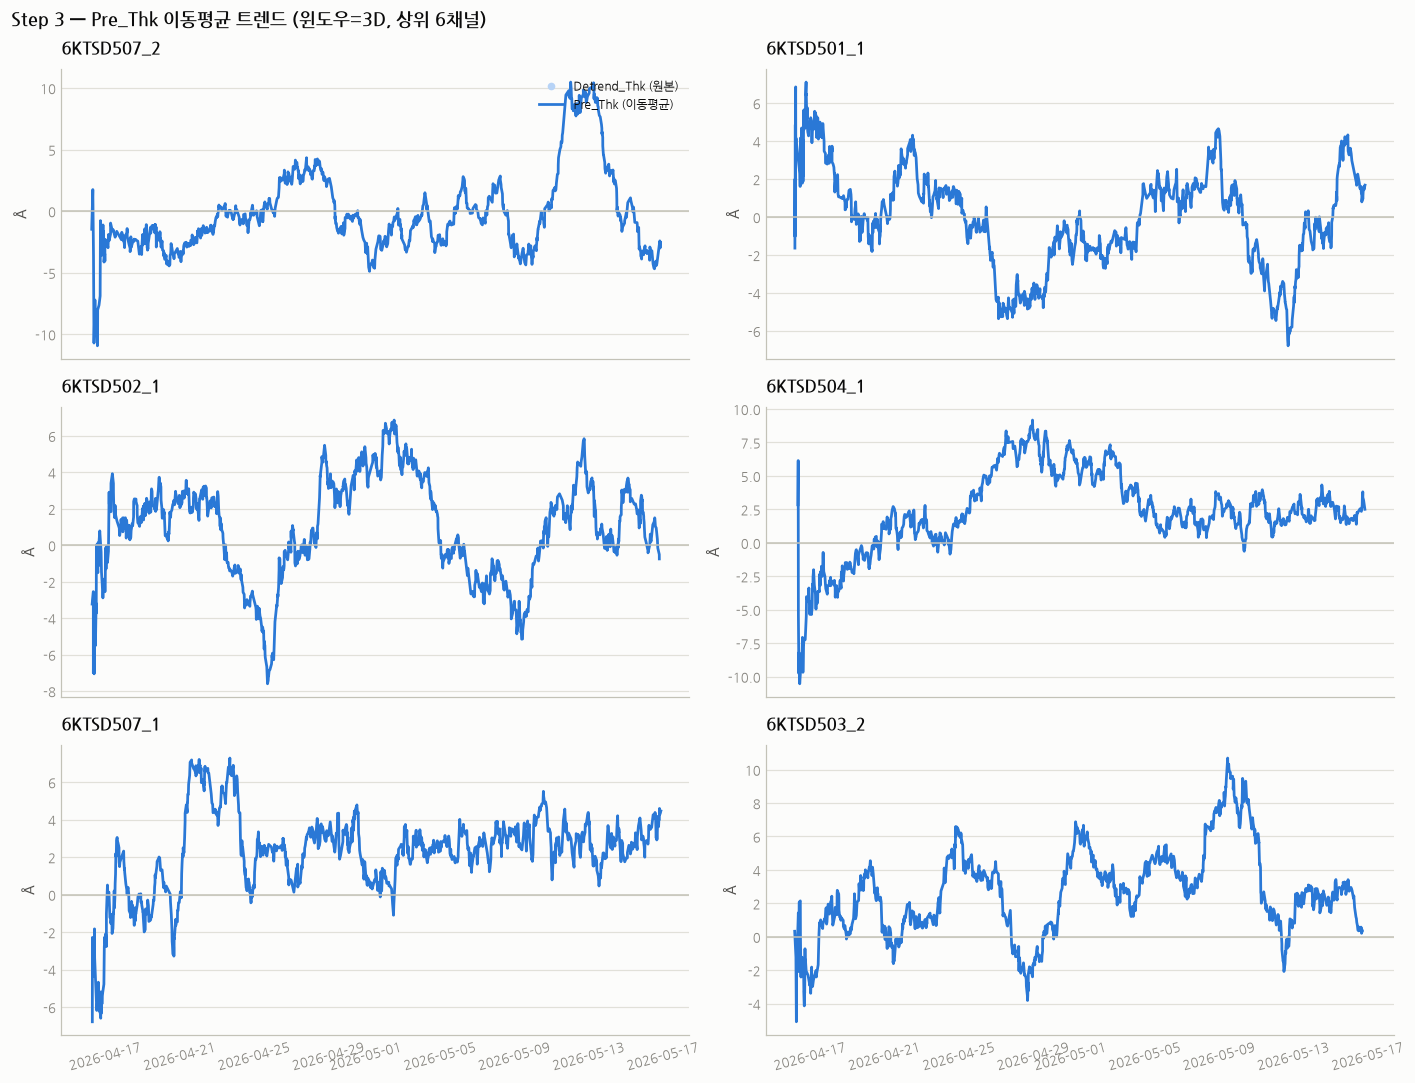

In [11]:
top_ch = (valid.groupby('pre_eq_ch')['Pre_Thk_Count'].max()
               .sort_values(ascending=False).head(6).index.tolist())

fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
fig.suptitle(f'Step 3 — Pre_Thk 이동평균 트렌드 (윈도우={Pre_Thk_Period}, 상위 6채널)',
             fontsize=12, fontweight='bold', color=INK_PRIMARY, x=0.01, ha='left')

for ax, ch in zip(axes.flatten(), top_ch):
    raw = pre_thk_df_filtered[pre_thk_df_filtered['pre_eq_ch'] == ch] if 'pre_eq_ch' in pre_thk_df_filtered.columns else pd.DataFrame()
    sub = valid[valid['pre_eq_ch'] == ch].sort_values('pre_oper_time')

    if not raw.empty:
        ax.scatter(raw['pre_oper_time'], raw['Detrend_Thk'], s=4, alpha=0.25, color=RAW_COLOR, linewidths=0)
    ax.plot(sub['pre_oper_time'], sub['Pre_Thk'], color=PALETTE[0], linewidth=1.8)
    ax.axhline(0, color=BASELINE, linewidth=1)
    style_ax(ax, title=ch, ylabel='Å', legend=False)
    ax.tick_params(axis='x', rotation=15)

axes[0, 0].scatter([], [], s=16, color=RAW_COLOR, label='Detrend_Thk (원본)')
axes[0, 0].plot([], [], color=PALETTE[0], linewidth=1.8, label='Pre_Thk (이동평균)')
axes[0, 0].legend(fontsize=8, frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

## Step 4 — `_extract_latest()` : 최신값 추출 → 최종 학습값

```python
# Common/Module.py
df['rank'] = df.groupby('pre_eq_ch')['pre_oper_time'].rank(method='first', ascending=False)
pre_thk_table = df[df['rank'] == 1]     # 채널별 가장 최근 1행만 최종 학습값으로 채택
```

In [12]:
from Common.Module import _extract_latest

pre_thk_df_rolled['THK_Para'] = Thk_Para
pre_thk_table = _extract_latest(
    pre_thk_df_rolled, cols=['pre_oper_time', 'pre_eq_ch', 'Pre_Thk', 'Pre_Thk_Count', 'THK_Para']
).sort_values('pre_eq_ch').reset_index(drop=True)

print(f'최종 Pre_Thk_VM 학습값: {len(pre_thk_table)}건 (채널별 최신 1건)')
pre_thk_table

최종 Pre_Thk_VM 학습값: 16건 (채널별 최신 1건)


,pre_oper_time,pre_eq_ch,Pre_Thk,Pre_Thk_Count,THK_Para
0,2026-05-16 20:47:27.854184,6KTSD501_1,1.674775,113.0,AMAT_POST_OCD_AVG
1,2026-05-16 20:59:30.952848,6KTSD501_2,1.045299,104.0,AMAT_POST_OCD_AVG
2,2026-05-16 19:32:57.701049,6KTSD502_1,-0.754716,109.0,AMAT_POST_OCD_AVG
3,2026-05-16 17:07:43.145359,6KTSD502_2,2.235004,127.0,AMAT_POST_OCD_AVG
4,2026-05-16 19:47:37.603730,6KTSD503_1,-2.222996,94.0,AMAT_POST_OCD_AVG
5,2026-05-16 17:05:00.440990,6KTSD503_2,0.341576,128.0,AMAT_POST_OCD_AVG
6,2026-05-16 20:37:55.768739,6KTSD504_1,2.498853,115.0,AMAT_POST_OCD_AVG
7,2026-05-16 20:36:08.791777,6KTSD504_2,1.961643,105.0,AMAT_POST_OCD_AVG
8,2026-05-16 17:51:02.586333,6KTSD505_1,0.681552,114.0,AMAT_POST_OCD_AVG
9,2026-05-16 20:59:28.442040,6KTSD505_2,1.449129,123.0,AMAT_POST_OCD_AVG


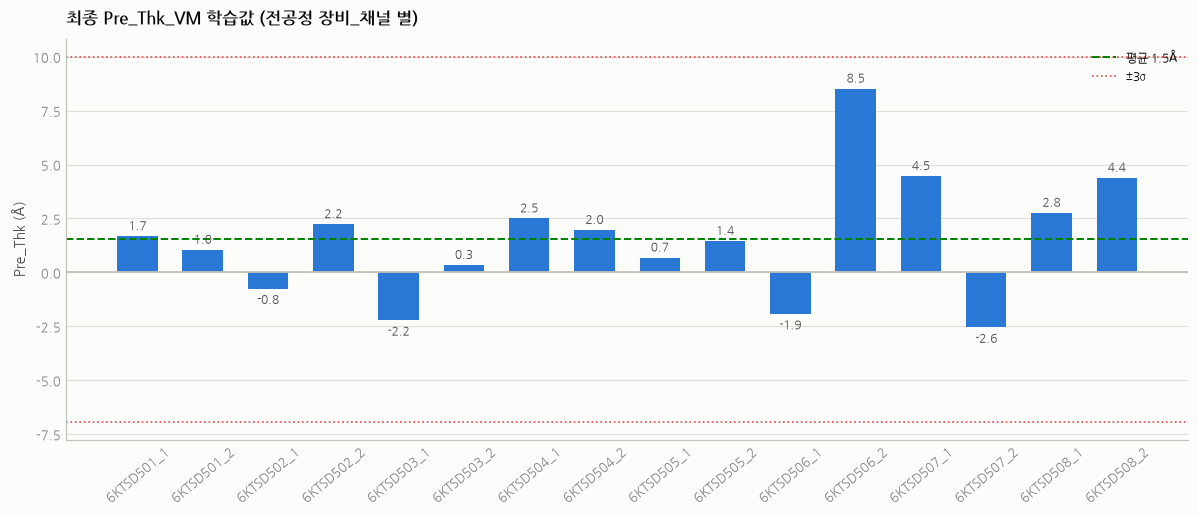

평균 1.53Å  |  표준편차 2.82Å  |  범위 -2.55 ~ 8.52Å


In [13]:
mean_v, std_v = pre_thk_table['Pre_Thk'].mean(), pre_thk_table['Pre_Thk'].std()

fig, ax = plt.subplots(figsize=(11, 4.8))
bars = ax.bar(pre_thk_table['pre_eq_ch'], pre_thk_table['Pre_Thk'], color=PALETTE[0], width=0.62)
ax.bar_label(bars, fmt='%.1f', fontsize=8, padding=3, color=INK_SECONDARY)
ax.axhline(0, color=BASELINE, linewidth=1.2)
ax.axhline(mean_v, color=PALETTE[3], linewidth=1.3, linestyle='--', label=f'평균 {mean_v:.1f}Å')
ax.axhline(mean_v + 3*std_v, color=PALETTE[5], linewidth=1.1, linestyle=':')
ax.axhline(mean_v - 3*std_v, color=PALETTE[5], linewidth=1.1, linestyle=':', label='±3σ')
style_ax(ax, title='최종 Pre_Thk_VM 학습값 (전공정 장비_채널 별)', ylabel='Pre_Thk (Å)')
ax.tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()
print(f'평균 {mean_v:.2f}Å  |  표준편차 {std_v:.2f}Å  |  범위 {pre_thk_table["Pre_Thk"].min():.2f} ~ {pre_thk_table["Pre_Thk"].max():.2f}Å')

## 정리

| Step | 함수 | 입력 → 출력 |
|---|---|---|
| 준비 | (Module.py 인라인 코드) | 두께 → BIAS (0-centering, 이 예제는 항상 0) |
| 1 | `PRE_THK_VM_Get.compute_detrend()` | 두께·연마시간 → Detrend_Thk (드리프트) |
| 2 | `PRE_THK_VM_Get.iqr_filter()` | Detrend_Thk → 이상치 제거된 Detrend_Thk |
| 3 | `PRE_THK_VM_Get.rolling_mean()` | Detrend_Thk → 채널별 Pre_Thk (이동평균) |
| 4 | `Common.Module._extract_latest()` | Pre_Thk → 채널별 최종 학습값 1건 |

실제 운영에서는 `Common/Module.py` 의 `Module_Get.compute_pre_thk_vm()` 함수가
Set-up 값에 따라 ITM/Detrend+MA/회귀 경로를 자동으로 선택해 위 Step들을
순서대로 실행하고, 결과를 MongoDB에 저장합니다. 이후 이 Pre_Thk_VM 학습값은
**Removal Rate 학습**(다음 교육 자료)에서 "전공정 두께 보정값"으로 사용됩니다.